# LLM-Assisted Explainable Misbehavior Reporting Framework for Cooperative Intelligent Transportation Systems

This project focuses on detecting and explaining misbehavior in Cooperative Intelligent Transportation Systems (C-ITS).

The VeReMi-based dataset contains vehicle communication records with information about vehicle identity, message timing, position, speed, acceleration, heading, and the corresponding misbehavior class.

The objective is to develop a machine learning-based misbehavior detection system and use Explainable AI (XAI) to understand the reasons behind model predictions. These explanations will later be converted into human-readable misbehavior reports with the help of an LLM.

In [1]:
# Core libraries
import os
import gc
import warnings

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics & machine learning
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Explainable AI
import shap

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# Project paths
# Project root = folder containing this notebook (portable; no hard-coded absolute path)
PROJECT_ROOT = os.path.abspath(".")
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "mixalldata_clean.csv")

# Chunk processing
CHUNK_SIZE = 200_000

print("Environment configured successfully.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")
print(f"Dataset exists: {os.path.exists(DATA_PATH)}")
print(f"Chunk size: {CHUNK_SIZE:,} rows")

Environment configured successfully.
Project root: <project root>
Dataset path: <project root>\data\mixalldata_clean.csv
Dataset exists: True
Chunk size: 200,000 rows


## Phase 1 — Data Understanding

The dataset contains individual vehicle communication records. Each row represents one received vehicle message at a particular time, along with the sender information, vehicle state, and the assigned misbehavior class.

Since the cleaned dataset contains more than 3 million records and is around 1 GB in size, the analysis will use chunk-based processing instead of loading the complete dataset into memory for every operation.

A chunk size of 200,000 rows is used throughout the initial data audit.

In [2]:
def process_chunks(path=DATA_PATH, chunk_size=CHUNK_SIZE):
    """Yield dataset chunks one at a time."""
    return pd.read_csv(path, chunksize=chunk_size)

def print_progress(chunk_no, rows_processed):
    if chunk_no == 1 or chunk_no % 5 == 0:
        print(f"Processed {rows_processed:,} rows...")

print("Chunk-processing functions ready.")

Chunk-processing functions ready.


### Dataset structure

Before analysing the data, we first verify the file, number of rows, columns, and basic data types.

In [3]:
# Read only the first chunk to inspect the dataset structure
sample = pd.read_csv(DATA_PATH, nrows=5)

print(f"Dataset path: {DATA_PATH}")
print(f"Sample shape: {sample.shape}")
print(f"Number of columns: {len(sample.columns)}")

print("\nColumns:")
for i, col in enumerate(sample.columns):
    print(f"{i}: {col}")

print("\nData types:")
print(sample.dtypes)

print("\nFirst 5 rows:")
display(sample)

Dataset path: <project root>\data\mixalldata_clean.csv
Sample shape: (5, 30)
Number of columns: 30

Columns:
0: type
1: sendTime
2: sender
3: senderPseudo
4: messageID
5: class
6: posx
7: posy
8: posz
9: posx_n
10: posy_n
11: posz_n
12: spdx
13: spdy
14: spdz
15: spdx_n
16: spdy_n
17: spdz_n
18: aclx
19: acly
20: aclz
21: aclx_n
22: acly_n
23: aclz_n
24: hedx
25: hedy
26: hedz
27: hedx_n
28: hedy_n
29: hedz_n

Data types:
type              int64
sendTime        float64
sender            int64
senderPseudo      int64
messageID         int64
class             int64
posx            float64
posy            float64
posz            float64
posx_n          float64
posy_n          float64
posz_n          float64
spdx            float64
spdy            float64
spdz            float64
spdx_n          float64
spdy_n          float64
spdz_n          float64
aclx            float64
acly            float64
aclz            float64
aclx_n          float64
acly_n          float64
aclz_n          float6

,type,sendTime,sender,senderPseudo,messageID,class,posx,posy,posz,posx_n,posy_n,posz_n,spdx,spdy,spdz,spdx_n,spdy_n,spdz_n,aclx,acly,aclz,aclx_n,acly_n,aclz_n,hedx,hedy,hedz,hedx_n,hedy_n,hedz_n
0,4,72002.302942,130137,101301377,422013806,0,266.982401,32.336955,0.0,3.480882,3.473184,0.0,-0.124661,1.206343,0.0,-0.000000,-0.000000,0.0,-0.219100,2.120328,0.0,0.000862,0.000862,0.0,-0.102790,0.994703,0.0,20.038218,17.541001,0.0
1,4,72003.302942,130137,101301377,422023410,0,266.827208,34.624145,0.0,3.546261,3.570524,0.0,-0.323739,3.132858,0.0,0.000107,-0.001040,0.0,-0.216966,2.099684,0.0,0.000107,0.001040,0.0,-0.099856,0.995002,0.0,20.441139,14.467283,0.0
2,4,72004.302942,130137,101301377,422032081,0,266.420297,38.836461,0.0,3.544045,3.432068,0.0,-0.522008,5.051538,0.0,0.000279,-0.002701,0.0,-0.184437,1.784944,0.0,0.000172,0.001661,0.0,-0.099856,0.995002,0.0,20.850473,11.941528,0.0
3,4,72005.302942,130137,101301377,422040712,0,268.912026,45.414229,0.0,3.340080,3.350806,0.0,-0.746193,7.198828,0.0,0.000450,-0.004356,0.0,-0.187751,1.811453,0.0,0.000171,0.001654,0.0,-0.100172,0.994970,0.0,21.323229,9.633965,0.0
4,4,72006.302942,130137,101301377,422052949,0,268.242276,53.729986,0.0,3.328872,3.319050,0.0,-0.961819,9.279121,0.0,0.000643,-0.006208,0.0,-0.258225,2.491295,0.0,0.000193,0.001852,0.0,-0.097105,0.995274,0.0,21.788034,7.824555,0.0


### Understanding one dataset record

Each row represents a single vehicle communication message.

The main groups of variables are:

- `sendTime` — time at which the message was sent.
- `sender` — identifier of the actual vehicle/sender.
- `senderPseudo` — pseudonymous identifier used by the sender.
- `messageID` — unique identifier of the message.
- `class` — target label representing the type of behaviour.
- `posx`, `posy`, `posz` — vehicle position.
- `spdx`, `spdy`, `spdz` — vehicle speed components.
- `aclx`, `acly`, `aclz` — vehicle acceleration components.
- `hedx`, `hedy`, `hedz` — vehicle heading components.
- Variables ending in `_n` are the noise associated with them.

For this dataset, the `z` components are constant and will be examined later before deciding whether they should be retained.

For example, one row can be interpreted as:

> At a particular `sendTime`, vehicle `sender` transmitted `messageID`. The record contains its pseudonymous identity, position, speed, acceleration and heading information, and `class` tells us the behaviour category assigned to that message.

### Basic dataset audit

We now scan the complete dataset in chunks to establish the basic facts that will be used throughout the rest of the analysis.

In [4]:
total_rows = 0
class_counts = pd.Series(dtype="int64")

unique_senders = set()
unique_sender_pseudo = set()
unique_message_ids = set()

for chunk_no, chunk in enumerate(process_chunks(), start=1):
    total_rows += len(chunk)

    class_counts = class_counts.add(
        chunk["class"].value_counts(),
        fill_value=0
    )

    unique_senders.update(chunk["sender"].unique())
    unique_sender_pseudo.update(chunk["senderPseudo"].unique())
    unique_message_ids.update(chunk["messageID"].unique())

    print_progress(chunk_no, total_rows)

class_counts = class_counts.astype(int).sort_index()

print("\n--- Dataset summary ---")
print(f"Total records: {total_rows:,}")
print(f"Number of classes: {len(class_counts)}")
print(f"Unique senders: {len(unique_senders):,}")
print(f"Unique senderPseudo values: {len(unique_sender_pseudo):,}")
print(f"Unique message IDs: {len(unique_message_ids):,}")

print("\n--- Class distribution ---")
display(class_counts.to_frame("records"))

Processed 200,000 rows...


Processed 1,000,000 rows...


Processed 2,000,000 rows...


Processed 3,000,000 rows...



--- Dataset summary ---
Total records: 3,194,808
Number of classes: 20
Unique senders: 24,663
Unique senderPseudo values: 118,909
Unique message IDs: 3,194,808

--- Class distribution ---


,records
class,
0,1900539
1,43653
2,43567
3,43857
4,42575
5,41925
6,44359
7,42258
8,42583


### Initial findings

The audit establishes the basic structure of the dataset:

- **3,194,808 records** are present.
- There are **20 classes**, numbered from **0 to 19**.
- There are **24,663 unique senders**.
- There are **118,909 unique senderPseudo values**.
- Every message has a unique `messageID`.
- Class 0 is by far the largest class, so the target distribution is strongly imbalanced.

The class distribution will therefore need to be considered carefully during model development rather than relying only on overall accuracy.

### Target variable

The `class` column is the target variable for the misbehavior classification task.

Before moving into data-quality checks, we verify that the dataset contains the expected class IDs and that no unexpected labels are present.

In [5]:
observed_classes = sorted(class_counts.index.tolist())
expected_classes = list(range(20))

print(f"Expected class IDs: {expected_classes[0]}–{expected_classes[-1]}")
print(f"Observed class IDs: {observed_classes}")

if observed_classes == expected_classes:
    print("RESULT: Class column contains only integer IDs 0–19.")
else:
    print("RESULT: Unexpected or missing class IDs detected.")

Expected class IDs: 0–19
Observed class IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
RESULT: Class column contains only integer IDs 0–19.


### Class distribution

The dataset contains one normal class and multiple faulty and attack behaviours. The distribution is not uniform: class 0 contains about **1.9 million records**, while several other classes contain around **40–45 thousand records**.

Some classes are considerably larger, so class imbalance will be an important consideration when evaluating the classification models.

In [6]:
class_distribution = pd.DataFrame({
    "records": class_counts,
    "percentage": (class_counts / total_rows * 100).round(2)
})

display(class_distribution)

,records,percentage
class,,
0,1900539,59.49
1,43653,1.37
2,43567,1.36
3,43857,1.37
4,42575,1.33
5,41925,1.31
6,44359,1.39
7,42258,1.32
8,42583,1.33


### Class distribution

The target variable is highly imbalanced. Class 0 accounts for 59.49% of all records, while most of the remaining classes contribute around 1–4% each.

This imbalance is important for the later classification stage because overall accuracy alone may not represent how well the model detects the less frequent misbehavior classes.

In [7]:
# Output folders for figures and results

FIGURE_DIR = os.path.join(PROJECT_ROOT, "outputs", "figures")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "outputs", "results")

os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Figures will be saved to: {FIGURE_DIR}")
print(f"Results will be saved to: {RESULTS_DIR}")

Figures will be saved to: <project root>\outputs\figures
Results will be saved to: <project root>\outputs\results


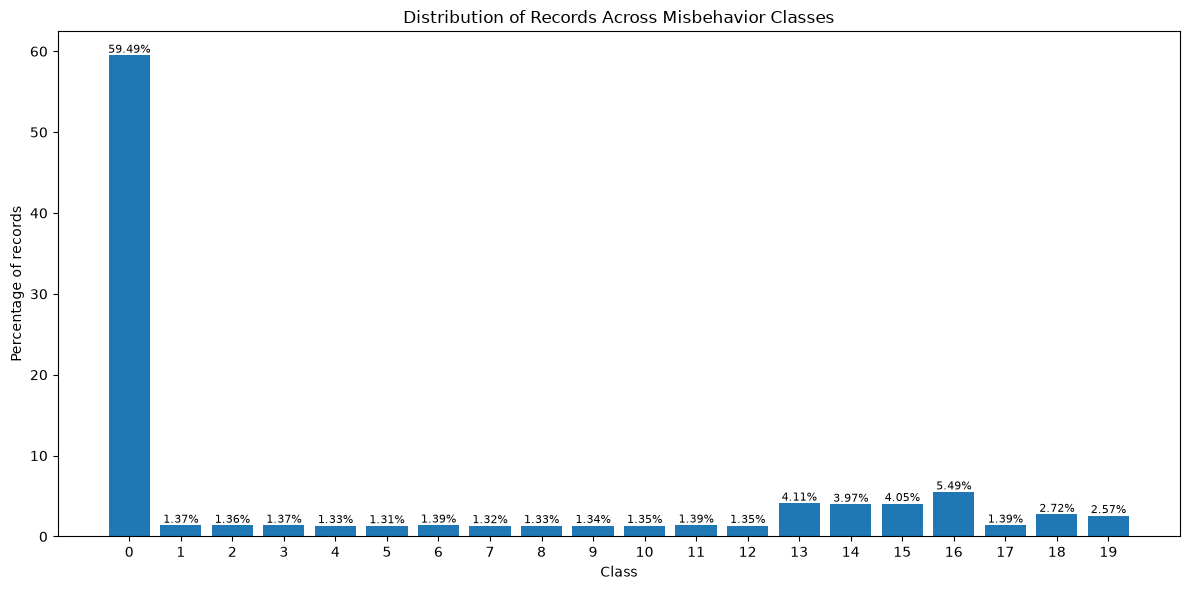

Figure saved: <project root>\outputs\figures\class_distribution.png


In [8]:
# Class distribution plot

plt.figure(figsize=(12, 6))

bars = plt.bar(
    class_distribution.index.astype(str),
    class_distribution["percentage"]
)

plt.xlabel("Class")
plt.ylabel("Percentage of records")
plt.title("Distribution of Records Across Misbehavior Classes")

for bar, value in zip(bars, class_distribution["percentage"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()

# Save for later use in report/presentation
figure_path = os.path.join(FIGURE_DIR, "class_distribution.png")
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved: {figure_path}")

## Phase 2 — Data Quality & Integrity

### Missing-value check

We now check every column across the complete dataset. Missing values can affect both exploratory analysis and model training, so this needs to be established before feature preparation.

In [9]:
missing_counts = pd.Series(0, index=sample.columns, dtype="int64")

for chunk_no, chunk in enumerate(process_chunks(), start=1):
    missing_counts = missing_counts.add(chunk.isna().sum(), fill_value=0).astype("int64")
    print_progress(chunk_no, total_rows if chunk_no == 1 else 0)

print("--- Missing values by column ---")
display(missing_counts.to_frame("missing_values"))

if missing_counts.sum() == 0:
    print("RESULT: No missing values found in the full dataset.")
else:
    print(f"RESULT: {missing_counts.sum():,} missing values found.")

Processed 3,194,808 rows...


Processed 0 rows...


Processed 0 rows...


Processed 0 rows...


--- Missing values by column ---


,missing_values
type,0
sendTime,0
sender,0
senderPseudo,0
messageID,0
class,0
posx,0
posy,0
posz,0
posx_n,0


RESULT: No missing values found in the full dataset.


### Duplicate records

A duplicate check is performed to make sure the same complete message record has not been stored more than once.

The check is performed in chunks and uses row hashes, so the complete dataset does not need to be kept in memory.

In [10]:
# Exact duplicate check using chunk-wise row hashes

unique_hashes = np.array([], dtype=np.uint64)
total_checked = 0

for chunk_no, chunk in enumerate(process_chunks(), start=1):
    hashes = pd.util.hash_pandas_object(chunk, index=False).to_numpy(dtype=np.uint64)

    # Keep only unique hashes from the current chunk
    chunk_unique = np.unique(hashes)

    # Merge with hashes already observed
    unique_hashes = np.union1d(unique_hashes, chunk_unique)

    total_checked += len(chunk)

    if chunk_no == 1 or chunk_no % 5 == 0:
        print(f"Processed {total_checked:,} rows...")

exact_duplicates = total_checked - len(unique_hashes)

print(f"\nRows checked: {total_checked:,}")
print(f"Unique row hashes: {len(unique_hashes):,}")
print(f"Exact duplicate rows: {exact_duplicates:,}")

if exact_duplicates == 0:
    print("RESULT: No exact duplicate rows found.")
else:
    print(f"RESULT: {exact_duplicates:,} exact duplicate rows found.")

Processed 200,000 rows...


Processed 1,000,000 rows...


Processed 2,000,000 rows...


Processed 3,000,000 rows...



Rows checked: 3,194,808
Unique row hashes: 3,194,808
Exact duplicate rows: 0
RESULT: No exact duplicate rows found.


The complete dataset contains **3,194,808 rows and no exact duplicate records**.

This means there is no evidence of identical rows being repeated in the dataset. The dataset can therefore move forward without removing exact duplicates at this stage.

### Sender-level class consistency

Each `sender` represents a vehicle. We check whether the same vehicle appears with different class labels.

This is important because a sender appearing under multiple classes could indicate either genuine behaviour changes or a possible issue in how the dataset is labelled.

In [11]:
# Check whether a sender is associated with more than one class

sender_classes = {}

total_rows_checked = 0

for chunk_no, chunk in enumerate(process_chunks(), start=1):

    pairs = chunk[["sender", "class"]].drop_duplicates()

    for sender, cls in pairs.itertuples(index=False):
        if sender not in sender_classes:
            sender_classes[sender] = {cls}
        else:
            sender_classes[sender].add(cls)

    total_rows_checked += len(chunk)

    if chunk_no == 1 or chunk_no % 5 == 0:
        print(f"Processed {total_rows_checked:,} rows...")

classes_per_sender = pd.Series(
    {sender: len(classes) for sender, classes in sender_classes.items()},
    name="unique_classes"
)

multi_class_senders = (classes_per_sender > 1).sum()

print("\n--- Class consistency within senders ---")
print(f"Total senders: {len(classes_per_sender):,}")
print(f"Senders with exactly one class: {(classes_per_sender == 1).sum():,}")
print(f"Senders with more than one class: {multi_class_senders:,}")
print(f"Maximum classes observed for one sender: {classes_per_sender.max()}")
print(f"Senders whose class changes over their sequence: {multi_class_senders:,}")

print("\n--- Distribution of number of classes per sender ---")
display(classes_per_sender.value_counts().sort_index().to_frame("senders"))

Processed 200,000 rows...


Processed 1,000,000 rows...


Processed 2,000,000 rows...


Processed 3,000,000 rows...



--- Class consistency within senders ---
Total senders: 24,663
Senders with exactly one class: 24,663
Senders with more than one class: 0
Maximum classes observed for one sender: 1
Senders whose class changes over their sequence: 0

--- Distribution of number of classes per sender ---


,senders
unique_classes,
1,24663


All **24,663 senders are associated with exactly one class**.

No sender changes class anywhere in the dataset. This is an important structural property of the dataset: the class label is effectively fixed at the sender level.

Because of this, a random row-wise train/test split could place records from the same vehicle in both sets and make the model evaluation overly optimistic. This will be considered carefully when we design the final train/test strategy.

### Sender pseudonym audit

`sender` identifies the underlying vehicle, while `senderPseudo` represents the pseudonymous identity used in the communication data.

We check how pseudonyms are distributed across vehicles and whether a pseudonym is shared by multiple senders. This is particularly relevant because several attack classes involve changes or multiple identities.

In [12]:
# Audit senderPseudo relationships

sender_pseudo_counts = {}
pseudo_sender_counts = {}

for chunk_no, chunk in enumerate(process_chunks(), start=1):

    pairs = chunk[["sender", "senderPseudo"]].drop_duplicates()

    for sender, pseudo in pairs.itertuples(index=False):
        sender_pseudo_counts.setdefault(sender, set()).add(pseudo)
        pseudo_sender_counts.setdefault(pseudo, set()).add(sender)

    if chunk_no == 1 or chunk_no % 5 == 0:
        print(f"Processed chunk {chunk_no}...")

sender_pseudo_summary = pd.Series(
    {sender: len(pseudos) for sender, pseudos in sender_pseudo_counts.items()},
    name="senderPseudo_count"
)

pseudo_sender_summary = pd.Series(
    {pseudo: len(senders) for pseudo, senders in pseudo_sender_counts.items()},
    name="sender_count"
)

shared_pseudos = pseudo_sender_summary[pseudo_sender_summary > 1]

print("\n--- SenderPseudo audit ---")
print(f"Unique senderPseudo values: {len(pseudo_sender_summary):,}")

print("\nSenderPseudo values per sender:")
print(sender_pseudo_summary.describe())

print(f"\nMaximum pseudonyms used by one sender: {sender_pseudo_summary.max():,}")
print(f"SenderPseudo values associated with more than one sender: {len(shared_pseudos):,}")

if len(shared_pseudos) > 0:
    print(f"Maximum number of senders associated with one senderPseudo: {shared_pseudos.max():,}")
else:
    print("Maximum number of senders associated with one senderPseudo: 1")

Processed chunk 1...


Processed chunk 5...


Processed chunk 10...


Processed chunk 15...



--- SenderPseudo audit ---
Unique senderPseudo values: 118,909

SenderPseudo values per sender:
count    24663.000000
mean         4.836597
std         18.070063
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        100.000000
Name: senderPseudo_count, dtype: float64

Maximum pseudonyms used by one sender: 100
SenderPseudo values associated with more than one sender: 1
Maximum number of senders associated with one senderPseudo: 377


The dataset contains **118,909 unique pseudonymous identifiers**.

Most senders use only one pseudonym, but some senders use many pseudonyms. One unusual case is also present: `senderPseudo = 1` is associated with **377 different senders**.

This means `senderPseudo` should not be treated as a direct replacement for `sender`. The two identifiers represent different aspects of vehicle identity and should be handled separately during feature selection.

### Message timing

The dataset represents vehicle communication over time, so the ordering and spacing of `sendTime` values need to be understood before creating any sequential or temporal features.

The analysis is performed within each sender rather than assuming that the complete CSV is globally sorted.

In [13]:
# Global and class-level sendTime audit

sendtime_min = np.inf
sendtime_max = -np.inf

global_previous_time = None
global_negative_gaps = 0
global_zero_gaps = 0
global_min_gap = np.inf
global_max_gap = -np.inf

class_time_stats = {}

total_rows_checked = 0

for chunk_no, chunk in enumerate(process_chunks(), start=1):

    times = chunk["sendTime"].to_numpy()

    sendtime_min = min(sendtime_min, times.min())
    sendtime_max = max(sendtime_max, times.max())

    # Global ordering check
    if global_previous_time is not None:
        first_gap = times[0] - global_previous_time
        global_min_gap = min(global_min_gap, first_gap)
        global_max_gap = max(global_max_gap, first_gap)

        if first_gap < 0:
            global_negative_gaps += 1
        elif first_gap == 0:
            global_zero_gaps += 1

    chunk_gaps = np.diff(times)

    if len(chunk_gaps):
        global_min_gap = min(global_min_gap, chunk_gaps.min())
        global_max_gap = max(global_max_gap, chunk_gaps.max())
        global_negative_gaps += np.sum(chunk_gaps < 0)
        global_zero_gaps += np.sum(chunk_gaps == 0)

    global_previous_time = times[-1]

    # Class-wise timing statistics
    grouped = chunk.groupby("class")["sendTime"].agg(["min", "max", "nunique"])

    for cls, row in grouped.iterrows():
        if cls not in class_time_stats:
            class_time_stats[cls] = {
                "min": row["min"],
                "max": row["max"],
                "nunique": row["nunique"]
            }
        else:
            class_time_stats[cls]["min"] = min(
                class_time_stats[cls]["min"], row["min"]
            )
            class_time_stats[cls]["max"] = max(
                class_time_stats[cls]["max"], row["max"]
            )
            class_time_stats[cls]["nunique"] += row["nunique"]

    total_rows_checked += len(chunk)

    if chunk_no == 1 or chunk_no % 5 == 0:
        print(f"Processed {total_rows_checked:,} rows...")

class_time_stats = pd.DataFrame(class_time_stats).T
class_time_stats.index.name = "class"

print("\n--- sendTime statistics ---")
print(f"Minimum sendTime: {sendtime_min}")
print(f"Maximum sendTime: {sendtime_max}")

print("\n--- Global ordering ---")
print(f"sendTime globally non-decreasing: {global_negative_gaps == 0}")

print("\n--- Consecutive sendTime gaps ---")
print(f"Minimum gap: {global_min_gap}")
print(f"Maximum gap: {global_max_gap}")
print(f"Number of negative gaps: {global_negative_gaps:,}")
print(f"Number of zero gaps: {global_zero_gaps:,}")

print("\n--- sendTime range by class ---")
display(class_time_stats.sort_index())

Processed 200,000 rows...


Processed 1,000,000 rows...


Processed 2,000,000 rows...


Processed 3,000,000 rows...



--- sendTime statistics ---
Minimum sendTime: 240.602763370378
Maximum sendTime: 86399.98493806412

--- Global ordering ---
sendTime globally non-decreasing: False

--- Consecutive sendTime gaps ---
Minimum gap: -72017.6762123222
Maximum gap: 68517.87588980678
Number of negative gaps: 24,417
Number of zero gaps: 0

--- sendTime range by class ---


,min,max,nunique
class,,,
0,240.602763,86399.984938,1900539.0
1,302.149675,86366.452438,43653.0
2,1208.814585,86399.095528,43567.0
3,754.099615,86397.264108,43857.0
4,1722.561399,86137.575432,42575.0
5,1398.632939,86399.812548,41925.0
6,2622.102183,86177.851759,44359.0
7,4195.424364,86345.156296,42258.0
8,2825.884878,86171.934362,42583.0


### Within-sender message intervals

Global ordering is not guaranteed in the dataset, so the more meaningful temporal check is performed separately for each sender.

We calculate the time difference between consecutive messages from the same vehicle. This helps determine the normal message interval and whether there are unusual gaps that may be useful for later feature engineering.

In [14]:
# Within-sender time-gap analysis

previous_times = {}
gap_values = []

total_rows_checked = 0

for chunk_no, chunk in enumerate(process_chunks(), start=1):

    # Sort only the current chunk by sender and time
    chunk = chunk.sort_values(["sender", "sendTime"])

    for sender, group in chunk.groupby("sender", sort=False):
        times = group["sendTime"].to_numpy()

        if sender in previous_times:
            gap = times[0] - previous_times[sender]
            gap_values.append(gap)

        if len(times) > 1:
            gaps = np.diff(times)
            gap_values.extend(gaps)

        previous_times[sender] = times[-1]

    total_rows_checked += len(chunk)

    if chunk_no == 1 or chunk_no % 5 == 0:
        print(f"Processed {total_rows_checked:,} rows...")

gap_values = np.asarray(gap_values, dtype=np.float64)

print(f"\nTotal within-sender time gaps: {len(gap_values):,}")

print("\n--- Within-sender time-gap statistics ---")
print(pd.Series(gap_values).describe())

print("\n--- Selected gap quantiles ---")
print(
    pd.Series(gap_values).quantile(
        [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00]
    )
)

print(f"\nNumber of gaps <= 0: {(gap_values <= 0).sum():,}")
print(f"Number of gaps < 0: {(gap_values < 0).sum():,}")

one_second_gaps = np.isclose(gap_values, 1.0)

print(f"Number of gaps == 1 second: {one_second_gaps.sum():,}")
print(
    f"Percentage of gaps approximately 1 second: "
    f"{one_second_gaps.mean() * 100:.2f} %"
)

Processed 200,000 rows...


Processed 1,000,000 rows...


Processed 2,000,000 rows...


Processed 3,000,000 rows...



Total within-sender time gaps: 3,170,145

--- Within-sender time-gap statistics ---
count    3.170145e+06
mean     8.501804e-01
std      2.823624e-01
min      1.666667e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

--- Selected gap quantiles ---


0.00    0.166667
0.01    0.166667
0.05    0.250000
0.25    1.000000
0.50    1.000000
0.75    1.000000
0.95    1.000000
0.99    1.000000
1.00    1.000000
dtype: float64

Number of gaps <= 0: 0
Number of gaps < 0: 0
Number of gaps == 1 second: 2,440,808
Percentage of gaps approximately 1 second: 76.99 %


The temporal audit shows that the CSV is **not globally ordered by `sendTime`**, but the individual vehicle sequences are well behaved.

Within a sender:

- There are **3,170,145 positive time gaps**.
- No negative or zero gaps were found.
- The median interval is **1 second**.
- About **76.99%** of the intervals are approximately 1 second.
- The minimum observed interval is about **0.167 seconds**.

This confirms that sender-level sequences are suitable for further temporal analysis and feature engineering. It also reinforces the need to perform sequence-based operations **within each sender**, rather than relying on the original row order of the CSV.

## Data validation checkpoint

At this stage, the dataset has passed the main structural and integrity checks:

- **3,194,808 records**
- **30 columns**
- **20 target classes**
- **No missing values**
- **No exact duplicate rows**
- **24,663 unique senders**
- Every sender is associated with **one class**
- **118,909 unique sender pseudonyms**
- `sendTime` is not globally ordered, but sender-level sequences are consistent
- Most within-sender messages occur at approximately **1-second intervals**

The dataset is therefore ready for the next stage: **feature-level exploratory analysis and feature suitability assessment**.

### Feature inventory

Before feature engineering, we review the role and variability of each column.

Constant columns carry no information for classification, while identifier columns may allow the model to memorize individual records or vehicles instead of learning misbehavior patterns. These columns therefore need to be separated from the actual behavioral features.

In [15]:
# Feature inventory using chunk-wise cardinality tracking
# Only categorical/identifier columns are tracked exactly to avoid high memory usage.

columns = sample.columns.tolist()

constant_candidates = []
unique_candidates = []

# Columns where exact unique values are useful and memory-safe
tracked_columns = ["type", "sender", "senderPseudo", "messageID", "class"]

unique_sets = {col: set() for col in tracked_columns}

total_rows = 0

for chunk_no, chunk in enumerate(process_chunks(), start=1):

    total_rows += len(chunk)

    for col in tracked_columns:
        unique_sets[col].update(chunk[col].unique().tolist())

    if chunk_no == 1 or chunk_no % 5 == 0:
        print(f"Processed {total_rows:,} rows...")

feature_inventory = pd.DataFrame({
    "dtype": sample[tracked_columns].dtypes.astype(str),
    "unique_values": [len(unique_sets[col]) for col in tracked_columns],
    "unique_ratio": [
        len(unique_sets[col]) / total_rows for col in tracked_columns
    ]
}, index=tracked_columns)

display(feature_inventory)

Processed 200,000 rows...


Processed 1,000,000 rows...


Processed 2,000,000 rows...


Processed 3,000,000 rows...


,dtype,unique_values,unique_ratio
type,int64,1,3.130079e-07
sender,int64,24663,7.719713e-03
senderPseudo,int64,118909,3.721945e-02
messageID,int64,3194808,1.000000e+00
class,int64,20,6.260157e-06


### Columns requiring special treatment

The audit identifies columns that are constant across the dataset or unique for every record.

These columns are not treated as ordinary behavioral features. The target `class` is retained separately, while identifiers and constant fields are excluded from the initial ML feature set.

In [16]:
# Identify constant and fully unique columns across the complete dataset

constant_columns = []
unique_columns = []

for col in sample.columns:

    if col in unique_sets:
        n_unique = len(unique_sets[col])

        if n_unique == 1:
            constant_columns.append(col)

        if n_unique == total_rows:
            unique_columns.append(col)

# Remaining numeric columns: min/max for all of them in a single pass over the file
other_cols = [c for c in sample.columns if c not in unique_sets]
values_min = pd.Series(np.inf, index=other_cols)
values_max = pd.Series(-np.inf, index=other_cols)

for chunk in process_chunks():
    values_min = np.minimum(values_min, chunk[other_cols].min())
    values_max = np.maximum(values_max, chunk[other_cols].max())

constant_columns += [c for c in other_cols if values_min[c] == values_max[c]]

constant_columns = list(dict.fromkeys(constant_columns))
unique_columns = list(dict.fromkeys(unique_columns))

print("Constant columns:")
print(constant_columns)

print("\nFully unique columns:")
print(unique_columns)

Constant columns:
['type', 'posz', 'posz_n', 'spdz', 'spdz_n', 'aclz', 'aclz_n', 'hedz', 'hedz_n']

Fully unique columns:
['messageID']


### Feature groups

The remaining variables describe four main aspects of vehicle behaviour: position, speed, acceleration and heading.

The `_n` variables represent the corresponding noise measurements. We will keep these variables for further analysis and decide their usefulness based on the data.

In [17]:
feature_groups = {
    "Position": ["posx", "posy", "posz"],
    "Position noise": ["posx_n", "posy_n", "posz_n"],
    "Speed": ["spdx", "spdy", "spdz"],
    "Speed noise": ["spdx_n", "spdy_n", "spdz_n"],
    "Acceleration": ["aclx", "acly", "aclz"],
    "Acceleration noise": ["aclx_n", "acly_n", "aclz_n"],
    "Heading": ["hedx", "hedy", "hedz"],
    "Heading noise": ["hedx_n", "hedy_n", "hedz_n"]
}

for group, columns in feature_groups.items():
    print(f"{group}: {columns}")

# Behavioural features used in the rest of the analysis: every grouped column that is not constant
behavioral_features = [
    col for columns in feature_groups.values() for col in columns
    if col not in constant_columns
]
print(f"\nBehavioural features ({len(behavioral_features)}): {behavioral_features}")


Position: ['posx', 'posy', 'posz']
Position noise: ['posx_n', 'posy_n', 'posz_n']
Speed: ['spdx', 'spdy', 'spdz']
Speed noise: ['spdx_n', 'spdy_n', 'spdz_n']
Acceleration: ['aclx', 'acly', 'aclz']
Acceleration noise: ['aclx_n', 'acly_n', 'aclz_n']
Heading: ['hedx', 'hedy', 'hedz']
Heading noise: ['hedx_n', 'hedy_n', 'hedz_n']

Behavioural features (16): ['posx', 'posy', 'posx_n', 'posy_n', 'spdx', 'spdy', 'spdx_n', 'spdy_n', 'aclx', 'acly', 'aclx_n', 'acly_n', 'hedx', 'hedy', 'hedx_n', 'hedy_n']


### Overall feature statistics

We now examine the numerical range and variation of the behavioural features across the complete dataset.

Since the dataset is large, the statistics are calculated chunk by chunk. This gives us an overall view of the features before comparing their behaviour across different classes.

In [18]:
# Calculate overall statistics for behavioural features using chunks

feature_sum = pd.Series(0.0, index=behavioral_features)
feature_sum_sq = pd.Series(0.0, index=behavioral_features)
feature_min = pd.Series(np.inf, index=behavioral_features)
feature_max = pd.Series(-np.inf, index=behavioral_features)
feature_count = pd.Series(0, index=behavioral_features, dtype="int64")

total_feature_rows = 0

for chunk_no, chunk in enumerate(process_chunks(), start=1):

    data = chunk[behavioral_features]

    feature_sum += data.sum()
    feature_sum_sq += (data ** 2).sum()
    feature_min = np.minimum(feature_min, data.min())
    feature_max = np.maximum(feature_max, data.max())
    feature_count += data.count()

    total_feature_rows += len(data)

    if chunk_no == 1 or chunk_no % 5 == 0:
        print(f"Processed {total_feature_rows:,} rows...")

feature_mean = feature_sum / feature_count

feature_variance = (
    feature_sum_sq / feature_count
    - feature_mean ** 2
).clip(lower=0)

feature_std = np.sqrt(feature_variance)

feature_stats = pd.DataFrame({
    "mean": feature_mean,
    "std": feature_std,
    "min": feature_min,
    "max": feature_max
})

display(feature_stats)

Processed 200,000 rows...


Processed 1,000,000 rows...


Processed 2,000,000 rows...


Processed 3,000,000 rows...


,mean,std,min,max
posx,599.019709,391.581064,-20.012992,1518.955691
posy,667.336637,305.649402,-22.479558,1522.608627
posx_n,3.982328,0.684549,0.000000,8.245800
posy_n,3.982727,0.685024,0.000000,8.292826
spdx,2.203564,10.237755,-26.993424,39.999988
spdy,2.470869,10.120777,-27.872256,39.999796
spdx_n,0.000102,0.012182,-0.108313,0.088924
spdy_n,0.000021,0.012143,-0.108254,0.107536
aclx,0.078316,1.017032,-6.999004,4.506170
acly,0.078859,1.153178,-4.499935,4.504408


### What the feature statistics show

The features are on very different numerical scales. Position values are in hundreds of units, speed is roughly within ±40, acceleration is much smaller, and the heading variables are bounded around -1 to 1.

The noise variables also have very different ranges. In particular, `hedx_n` and `hedy_n` have much larger values than the other noise variables.

At this stage, we will **not remove any behavioural feature based only on its scale**. Scaling and the usefulness of individual variables will be examined later during feature preparation and selection.

In [19]:
feature_stats.to_csv(
    os.path.join(RESULTS_DIR, "overall_feature_statistics.csv")
)

print("Feature statistics saved to:")
print(os.path.join(RESULTS_DIR, "overall_feature_statistics.csv"))

Feature statistics saved to:
<project root>\outputs\results\overall_feature_statistics.csv


### Class-wise feature behaviour

The overall statistics show the general range and variation of each behavioural feature. We now compare these features across the 20 misbehavior classes.

This will help us identify whether different classes show noticeable differences in vehicle position, speed, acceleration, heading, and their associated noise measurements. Since the dataset is large, the calculation is performed chunk by chunk.

In [20]:
# Calculate class-wise mean values using chunk-wise aggregation

class_feature_sum = pd.DataFrame(
    0.0,
    index=range(20),
    columns=behavioral_features
)

class_counts = pd.Series(
    0,
    index=range(20),
    dtype="int64"
)

total_rows_processed = 0

for chunk_no, chunk in enumerate(process_chunks(), start=1):

    grouped_sum = chunk.groupby("class")[behavioral_features].sum()
    grouped_count = chunk.groupby("class").size()

    class_feature_sum = class_feature_sum.add(
        grouped_sum,
        fill_value=0
    )

    class_counts = class_counts.add(
        grouped_count,
        fill_value=0
    ).astype("int64")

    total_rows_processed += len(chunk)

    if chunk_no == 1 or chunk_no % 5 == 0:
        print(f"Processed {total_rows_processed:,} rows...")

class_feature_mean = class_feature_sum.div(
    class_counts,
    axis=0
)

class_feature_mean.index.name = "class"

display(class_feature_mean)

Processed 200,000 rows...


Processed 1,000,000 rows...


Processed 2,000,000 rows...


Processed 3,000,000 rows...


,posx,posy,posx_n,posy_n,spdx,spdy,spdx_n,spdy_n,aclx,acly,aclx_n,acly_n,hedx,hedy,hedx_n,hedy_n
class,,,,,,,,,,,,,,,,
0,582.528901,663.008543,4.001423,4.001793,-0.087216,0.277985,0.000118,0.000052,0.003499,0.000004,0.001015,0.001125,-0.043292,0.043804,13.454620,13.089950
1,780.186441,700.985822,3.994704,3.993827,-0.534681,0.403492,0.000378,0.000152,0.004953,0.003491,0.000911,0.001046,-0.088015,0.064796,14.479375,13.519592
2,662.397685,739.489831,3.980003,3.981907,0.128560,0.226959,-0.000164,-0.000460,0.009914,0.000277,0.001061,0.001216,-0.031041,0.039244,13.713058,13.076656
3,752.687537,749.188250,4.017312,4.017233,-0.422435,-0.118240,-0.000236,-0.000159,0.004170,-0.003891,0.001062,0.001200,-0.085628,0.004681,13.458712,13.448497
4,572.347406,652.472839,4.006340,4.009048,0.158987,0.893429,0.000579,-0.000114,0.006654,0.001166,0.000969,0.001112,-0.002785,0.111091,12.536863,11.860918
5,583.658644,662.211342,3.919959,3.921066,21.128163,19.534412,0.000354,-0.000031,0.001874,0.002849,0.000894,0.001003,-0.013469,0.021185,13.065209,13.202049
6,576.848917,665.010345,3.930842,3.932080,6.555965,7.583253,-0.000461,-0.001014,0.005360,-0.000392,0.001040,0.001138,-0.092713,0.080267,13.890733,12.750301
7,597.615352,664.778034,3.992473,3.990585,19.962781,20.057112,0.000281,-0.000618,-0.001349,-0.000203,0.000996,0.001097,-0.089417,-0.019810,13.599511,13.247658
8,609.993067,680.397339,4.040141,4.040699,-0.241190,0.236875,0.000565,0.000975,0.014529,0.000788,0.001049,0.001126,-0.064875,0.032319,13.206671,12.527515


### Class-wise observations

The class-wise means show clear differences in several behavioural measurements.

- Classes 5, 7, 14 and 18 have much higher average speed values than the normal class.
- Classes 12 and 14 show noticeable differences in their average position compared with most other classes.
- Acceleration also changes substantially for some classes, particularly classes 10, 14 and 18.
- The noise features show smaller but still noticeable differences across some classes.

These differences suggest that the behavioural features contain useful information for distinguishing misbehavior classes. However, class means alone are not enough to determine feature importance, so we will examine the distributions and relationships between features next.

In [21]:
class_feature_mean.to_csv(
    os.path.join(RESULTS_DIR, "class_wise_feature_means.csv")
)

print("Class-wise feature means saved.")
print(os.path.join(RESULTS_DIR, "class_wise_feature_means.csv"))

Class-wise feature means saved.
<project root>\outputs\results\class_wise_feature_means.csv


### Average speed across classes

The class-wise statistics showed noticeable differences in speed between several misbehavior classes.

The following plot compares the average X and Y speed components across all 20 classes. This provides a clearer view of how speed-related behaviour varies between normal and misbehavior classes.

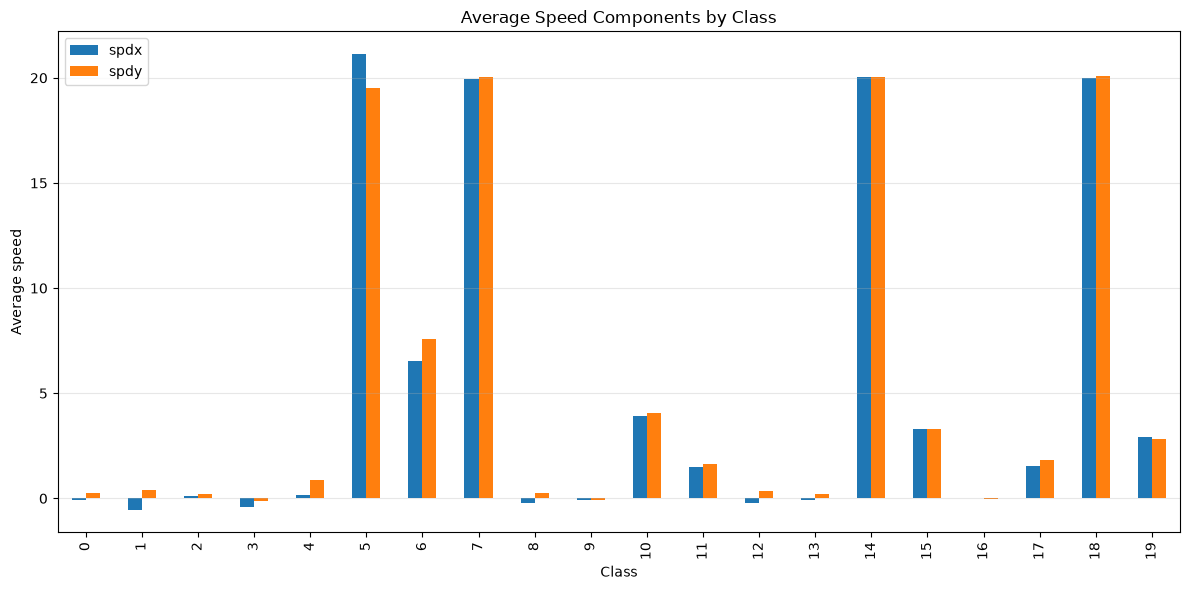

Figure saved to: <project root>\outputs\figures\average_speed_by_class.png


In [22]:
# Plot average speed components by class

speed_means = class_feature_mean[["spdx", "spdy"]]

ax = speed_means.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Average Speed Components by Class")
ax.set_xlabel("Class")
ax.set_ylabel("Average speed")
ax.legend(["spdx", "spdy"])
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

figure_path = os.path.join(
    FIGURE_DIR,
    "average_speed_by_class.png"
)

plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {figure_path}")

### Acceleration behaviour across classes

Speed alone does not fully describe vehicle behaviour, so we also examine the average acceleration components across classes.

The class-wise statistics showed particularly large differences for classes 14 and 18, while most other classes have acceleration values much closer to the normal class. This comparison helps identify whether acceleration-related behaviour can also distinguish different misbehavior classes.

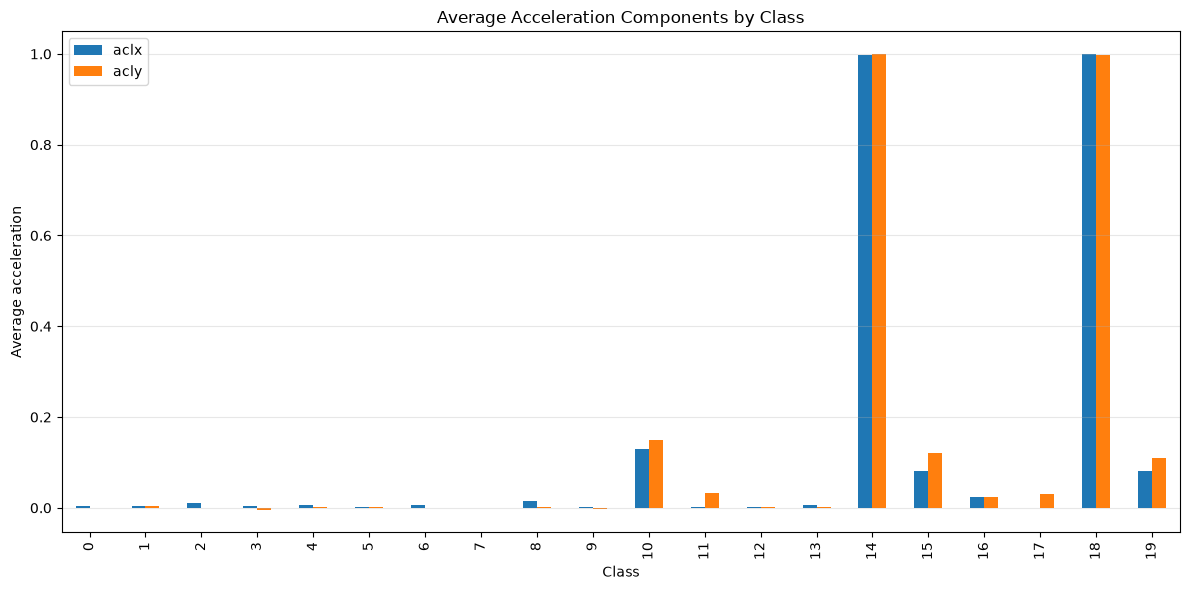

Figure saved to: <project root>\outputs\figures\average_acceleration_by_class.png


In [23]:
# Plot average acceleration components by class

acceleration_means = class_feature_mean[["aclx", "acly"]]

ax = acceleration_means.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Average Acceleration Components by Class")
ax.set_xlabel("Class")
ax.set_ylabel("Average acceleration")
ax.legend(["aclx", "acly"])
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

figure_path = os.path.join(
    FIGURE_DIR,
    "average_acceleration_by_class.png"
)

plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {figure_path}")

### Heading behaviour across classes

Heading describes the vehicle's movement direction through its X and Y components.

The class-wise statistics show that heading behaviour also varies between classes. Comparing the average heading components can help identify whether some misbehavior classes are associated with unusual directional patterns.

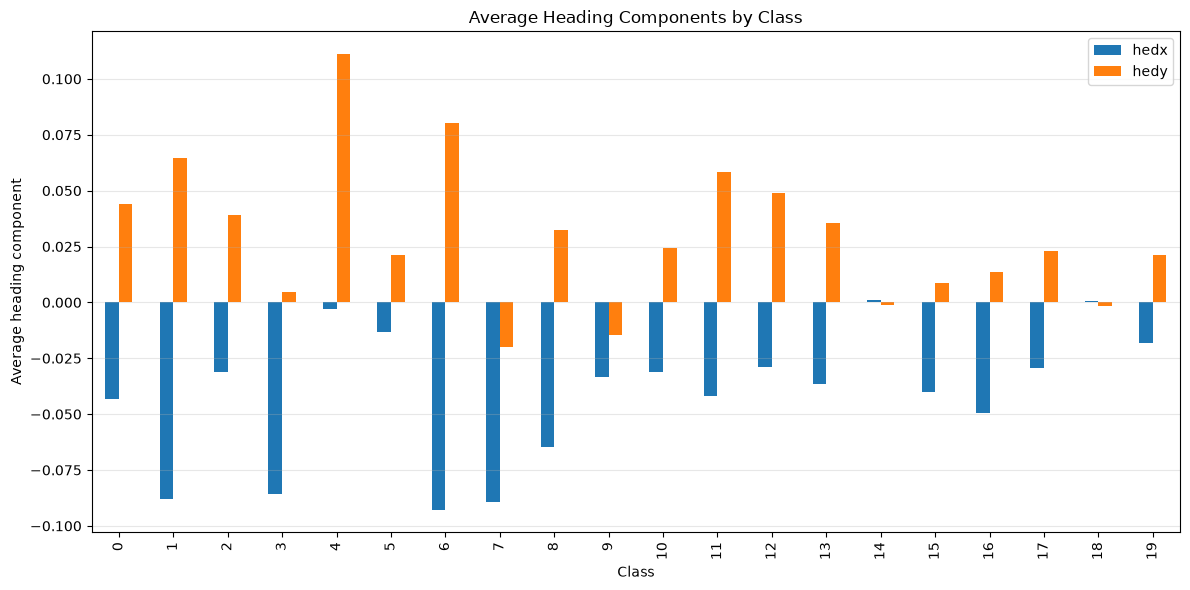

Figure saved to: <project root>\outputs\figures\average_heading_by_class.png


In [24]:
# Plot average heading components by class

heading_means = class_feature_mean[["hedx", "hedy"]]

ax = heading_means.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Average Heading Components by Class")
ax.set_xlabel("Class")
ax.set_ylabel("Average heading component")
ax.legend(["hedx", "hedy"])
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

figure_path = os.path.join(
    FIGURE_DIR,
    "average_heading_by_class.png"
)

plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {figure_path}")

### Noise behaviour across classes

The `_n` columns represent the noisy versions of the corresponding vehicle measurements.

Before using these variables for modelling, we check how their magnitude changes across classes. Large differences in noise between classes may themselves provide useful information about the type of misbehavior present in the data.

In [25]:
# Calculate average absolute noise by class

noise_features = [
    "posx_n", "posy_n",
    "spdx_n", "spdy_n",
    "aclx_n", "acly_n",
    "hedx_n", "hedy_n"
]

noise_sum = pd.DataFrame(
    0.0,
    index=range(20),
    columns=noise_features
)

noise_count = pd.Series(
    0,
    index=range(20),
    dtype="int64"
)

for chunk_no, chunk in enumerate(process_chunks(), start=1):

    grouped = chunk.groupby("class")[noise_features].agg(
        lambda x: np.abs(x).sum()
    )

    counts = chunk.groupby("class").size()

    for cls in grouped.index:
        noise_sum.loc[cls] += grouped.loc[cls]

    noise_count = noise_count.add(counts, fill_value=0).astype("int64")

    if chunk_no == 1 or chunk_no % 5 == 0:
        print(f"Processed chunk {chunk_no}...")

noise_mean_abs = noise_sum.div(noise_count, axis=0)

display(
    noise_mean_abs.round(6)
)

print("\nOverall average absolute noise:")
display(
    noise_mean_abs.mean().round(6).to_frame("mean_absolute_noise")
)

Processed chunk 1...


Processed chunk 5...


Processed chunk 10...


Processed chunk 15...


,posx_n,posy_n,spdx_n,spdy_n,aclx_n,acly_n,hedx_n,hedy_n
0,4.001423,4.001793,0.007814,0.008000,0.001015,0.001125,13.454620,13.089950
1,3.994704,3.993827,0.007104,0.007601,0.000911,0.001046,14.479375,13.519592
2,3.980003,3.981907,0.008513,0.008510,0.001061,0.001216,13.713058,13.076656
3,4.017312,4.017233,0.008045,0.008387,0.001062,0.001200,13.458712,13.448497
4,4.006340,4.009048,0.007488,0.008105,0.000969,0.001112,12.536863,11.860918
5,3.919959,3.921066,0.006861,0.007374,0.000894,0.001003,13.065209,13.202049
6,3.930842,3.932080,0.007987,0.007998,0.001040,0.001138,13.890733,12.750301
7,3.992473,3.990585,0.007608,0.007566,0.000996,0.001097,13.599511,13.247658
8,4.040141,4.040699,0.007896,0.007910,0.001049,0.001126,13.206671,12.527515
9,3.994584,3.998292,0.006218,0.006925,0.000965,0.001576,13.208009,12.306432



Overall average absolute noise:


,mean_absolute_noise
posx_n,3.902695
posy_n,3.903321
spdx_n,0.006971
spdy_n,0.007341
aclx_n,0.000979
acly_n,0.001124
hedx_n,13.078839
hedy_n,12.750224


### Noise relative to the original measurements

The raw noise values have different units and scales, so they cannot be compared directly.

Here we compare the average absolute noise with the average absolute value of the corresponding original feature. This gives a better idea of how large the noise is relative to the actual vehicle measurement.

Heading is **not** included in this comparison: `hedx`/`hedy` are unit-vector components (−1…1) while `hedx_n`/`hedy_n` take values up to ~120, i.e. they are on a different scale (the dataset paper does not define the `_n` fields), so a noise-to-signal ratio would be meaningless for heading.

In [26]:
# Compare noise magnitude with the corresponding original measurements

feature_pairs = {
    "Position X": ("posx", "posx_n"),
    "Position Y": ("posy", "posy_n"),
    "Speed X": ("spdx", "spdx_n"),
    "Speed Y": ("spdy", "spdy_n"),
    "Acceleration X": ("aclx", "aclx_n"),
    "Acceleration Y": ("acly", "acly_n")
}

signal_sum = pd.Series(0.0, index=[p[0] for p in feature_pairs.values()])
signal_count = pd.Series(0, index=signal_sum.index, dtype="int64")

noise_sum = pd.Series(0.0, index=signal_sum.index)

for chunk_no, chunk in enumerate(process_chunks(), start=1):

    for name, (signal, noise) in feature_pairs.items():
        signal_sum[signal] += chunk[signal].abs().sum()
        signal_count[signal] += chunk[signal].count()
        noise_sum[signal] += chunk[noise].abs().sum()

    if chunk_no == 1 or chunk_no % 5 == 0:
        print(f"Processed chunk {chunk_no}...")

signal_mean_abs = signal_sum / signal_count
noise_mean_abs = noise_sum / signal_count

relative_noise = (
    noise_mean_abs / signal_mean_abs * 100
).rename("noise_percentage")

noise_comparison = pd.DataFrame({
    "mean_absolute_signal": signal_mean_abs,
    "mean_absolute_noise": noise_mean_abs,
    "noise_percentage": relative_noise
})

display(noise_comparison.round(4))

Processed chunk 1...


Processed chunk 5...


Processed chunk 10...


Processed chunk 15...


,mean_absolute_signal,mean_absolute_noise,noise_percentage
posx,599.0200,3.9823,0.6648
posy,667.3368,3.9827,0.5968
spdx,7.2432,0.0073,0.1010
spdy,7.4099,0.0076,0.1024
aclx,0.6338,0.0010,0.1581
acly,0.7327,0.0011,0.1533


### Feature distributions

The class-wise means show that some behavioural features differ between classes, especially speed and acceleration.

We now look at their distributions to see how the values are spread and whether some classes show clearly different ranges or unusual values. Since the complete dataset is large, a representative sample is used for visualization rather than loading all records into memory.

In [27]:
# Create a representative sample for visual analysis

plot_features = [
    "posx", "posy",
    "spdx", "spdy",
    "aclx", "acly",
    "hedx", "hedy"
]

plot_sample = []
sample_per_chunk = 1000

for chunk_no, chunk in enumerate(process_chunks(), start=1):

    n = min(sample_per_chunk, len(chunk))

    if n > 0:
        plot_sample.append(
            chunk[plot_features + ["class"]].sample(
                n=n,
                random_state=42 + chunk_no
            )
        )

    if chunk_no == 1 or chunk_no % 5 == 0:
        print(f"Processed chunk {chunk_no}...")

plot_sample = pd.concat(plot_sample, ignore_index=True)

print(f"\nVisualization sample size: {len(plot_sample):,}")
print("Classes represented:", sorted(plot_sample["class"].unique()))

display(plot_sample.head())

Processed chunk 1...


Processed chunk 5...


Processed chunk 10...


Processed chunk 15...



Visualization sample size: 16,000
Classes represented: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]


,posx,posy,spdx,spdy,aclx,acly,hedx,hedy,class
0,219.593198,884.499253,-0.723783,4.698216,0.297371,-1.918535,-0.001272,0.999999,0
1,573.686610,268.347468,0.070955,27.275616,1.496620,1.796662,-0.933306,0.306227,18
2,877.121523,551.172244,-7.258455,-10.946917,-1.294157,-1.951930,-0.636127,-0.771585,0
3,235.077022,242.917708,3.913258,19.669946,0.055002,-0.365587,-0.122404,0.992480,6
4,794.791199,753.897638,-10.475900,-2.764845,-1.355371,-0.357692,-0.999612,-0.027863,0


### Behavioural feature distributions

The sampled data is used to examine how speed, acceleration, and heading values are distributed across the different classes.

These plots help identify whether the classes have visibly different behavioural patterns and whether some classes contain unusually wide or shifted distributions.

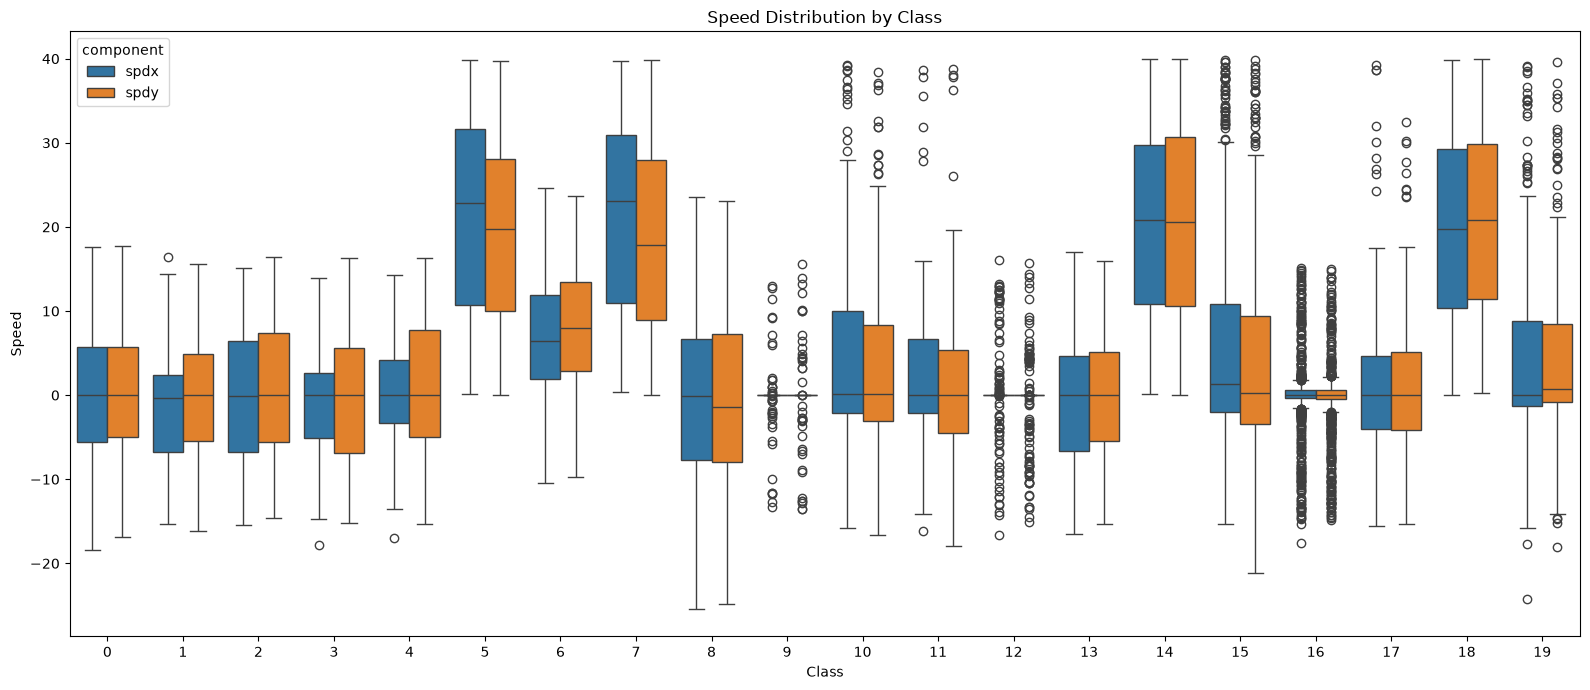

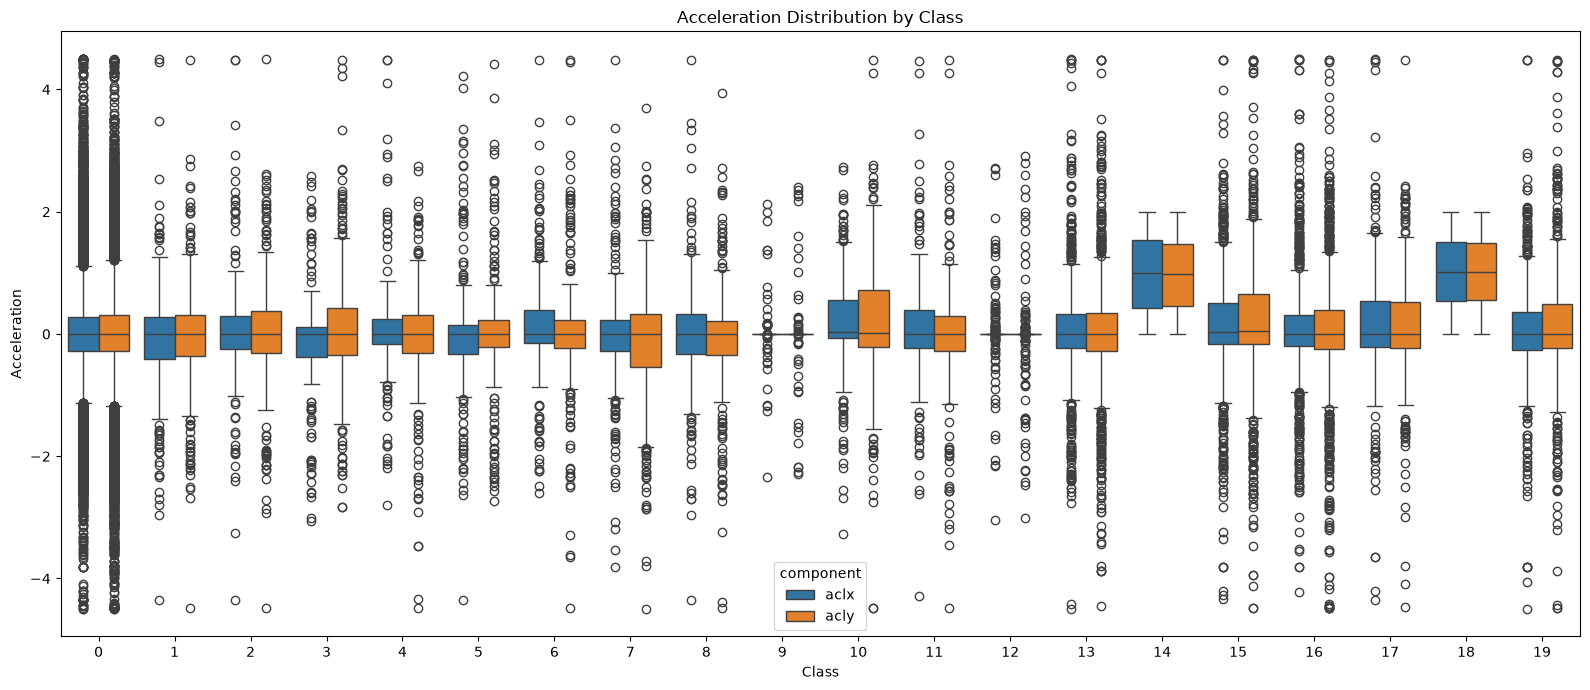

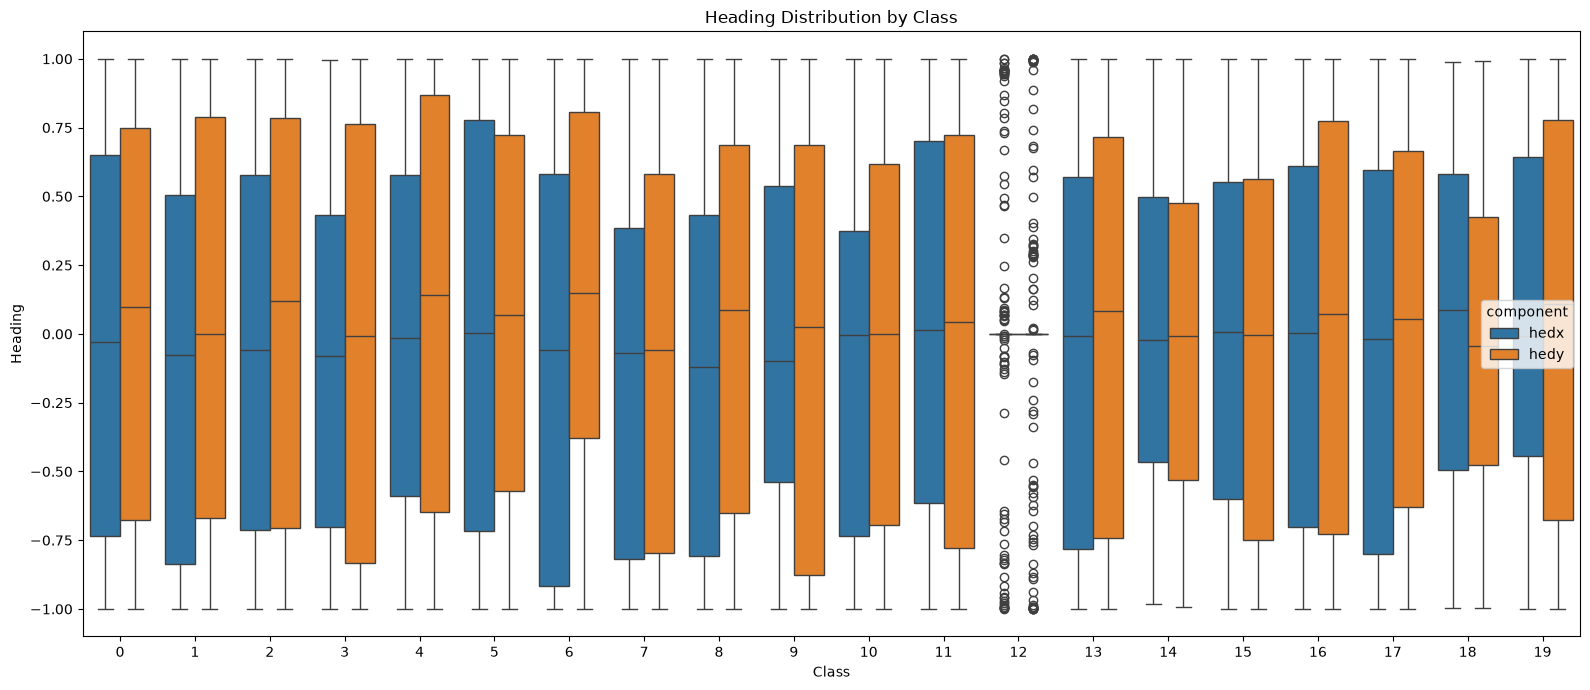

Figures saved to: <project root>\outputs\figures


In [28]:
# Class-wise distributions of key behavioural features

distribution_features = {
    "Speed": ["spdx", "spdy"],
    "Acceleration": ["aclx", "acly"],
    "Heading": ["hedx", "hedy"]
}

for feature_group, columns in distribution_features.items():

    plt.figure(figsize=(16, 7))

    plot_data = plot_sample.melt(
        id_vars="class",
        value_vars=columns,
        var_name="component",
        value_name="value"
    )

    sns.boxplot(
        data=plot_data,
        x="class",
        y="value",
        hue="component"
    )

    plt.title(f"{feature_group} Distribution by Class")
    plt.xlabel("Class")
    plt.ylabel(feature_group)
    plt.tight_layout()

    filename = f"{feature_group.lower()}_distribution_by_class.png"
    plt.savefig(
        os.path.join(FIGURE_DIR, filename),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

print(f"Figures saved to: {FIGURE_DIR}")

## Where to continue

This notebook covers Phases 1–3: data understanding, data quality and exploratory analysis (message level).

The vehicle-level structure of the data, the features, the models, the uncertainty of the results, the SHAP explanations, the report writer with its validator and the app are in `VeReMi_XAI_Part2.ipynb`.